# Exploratory Data Analysis (EDA) — Questionnaire Project

**Course:** MGS 3001 WHS01 — Python Programming for Business  
**Project Topic:** Consumer willingness to pay for AI-designed products  

This notebook follows the EDA style used in class and applies it to the cleaned questionnaire dataset.

**Input:** `questionnaire_cleaned.csv`  
**Focus:** descriptive statistics, group comparisons, correlations, and simple regression models


## The Big Picture: Where Does EDA Fit?

We have completed the project workflow:

**Collect → Clean → Transform → EDA → Visualize → Model → Report**

This notebook is the first analysis stage. The goal is to understand what the dataset contains before moving to more formal modeling.


## What Does EDA Produce for Your Paper?

This notebook generates outputs that can be used directly in the term paper:

- Descriptive statistics table  
- Group comparison table  
- Correlation matrix  
- Distribution plots  
- Initial regression results


## Section 0: Setup & Load

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 150

df = pd.read_csv(r"/mnt/data/questionnaire_cleaned.csv", encoding="utf-8-sig")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Shape: 212 rows × 21 columns


,group,consent,shopping_freq,ai_purchase,age_group,wtp_open,wtp_1,wtp_2,trust_1,trust_2,trust_3,fam_1,fam_2,fam_3,mc_ai,mc_value,design_source,added_value,wtp_score,trust_score,ai_familiarity
0,实验情境4,我同意并愿意继续作答,经常,否,28-32,121,5,6,6,4,6,5,4,2,1,2,0,0,5.5,5.333333,3.666667
1,实验情境4,我同意并愿意继续作答,经常,是,18-22,138,6,5,7,4,4,4,6,4,2,1,0,0,5.5,5.000000,4.666667
2,实验情境4,我同意并愿意继续作答,有时,否,33及以上,117,3,4,5,5,5,4,1,4,2,3,0,0,3.5,5.000000,3.000000
3,实验情境1,我同意并愿意继续作答,有时,是,18-22,177,5,6,6,6,5,7,4,5,6,6,1,1,5.5,5.666667,5.333333
4,实验情境4,我同意并愿意继续作答,偶尔,否,23-27,56,4,6,4,5,3,5,5,3,1,3,0,0,5.0,4.000000,4.333333


---  
## Section 1: Data Overview

The first step is always a diagnostic snapshot: shape, variable types, missing values, and summary statistics.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   group           212 non-null    object 
 1   consent         212 non-null    object 
 2   shopping_freq   212 non-null    object 
 3   ai_purchase     212 non-null    object 
 4   age_group       212 non-null    object 
 5   wtp_open        212 non-null    int64  
 6   wtp_1           212 non-null    int64  
 7   wtp_2           212 non-null    int64  
 8   trust_1         212 non-null    int64  
 9   trust_2         212 non-null    int64  
 10  trust_3         212 non-null    int64  
 11  fam_1           212 non-null    int64  
 12  fam_2           212 non-null    int64  
 13  fam_3           212 non-null    int64  
 14  mc_ai           212 non-null    int64  
 15  mc_value        212 non-null    int64  
 16  design_source   212 non-null    int64  
 17  added_value     212 non-null    int

In [3]:
print("Missing values by column:")
display(df.isnull().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())


Missing values by column:


,missing_count
group,0
consent,0
shopping_freq,0
ai_purchase,0
age_group,0
wtp_open,0
wtp_1,0
wtp_2,0
trust_1,0
trust_2,0



Duplicate rows: 0


In [4]:
numeric_cols = [
    "wtp_open", "wtp_1", "wtp_2",
    "trust_1", "trust_2", "trust_3",
    "fam_1", "fam_2", "fam_3",
    "mc_ai", "mc_value",
    "wtp_score", "trust_score", "ai_familiarity"
]

desc = df[numeric_cols].describe().T.round(2)
desc.columns = ["N", "Mean", "SD", "Min", "25%", "50%", "75%", "Max"]
desc


,N,Mean,SD,Min,25%,50%,75%,Max
wtp_open,212.0,158.34,45.19,56.00,126.00,156.50,187.00,283.00
wtp_1,212.0,5.18,1.01,2.00,5.00,5.00,6.00,7.00
wtp_2,212.0,5.10,1.05,2.00,4.00,5.00,6.00,7.00
trust_1,212.0,5.26,0.92,3.00,5.00,5.00,6.00,7.00
trust_2,212.0,5.28,0.88,3.00,5.00,5.00,6.00,7.00
trust_3,212.0,5.18,0.91,3.00,5.00,5.00,6.00,7.00
fam_1,212.0,4.33,1.12,1.00,4.00,4.00,5.00,7.00
fam_2,212.0,4.15,1.24,1.00,3.00,4.00,5.00,7.00
fam_3,212.0,4.21,1.11,1.00,4.00,4.00,5.00,7.00
mc_ai,212.0,3.83,2.34,1.00,2.00,3.00,6.00,7.00


In [5]:
print("=== Experimental groups ===")
display(df["group"].value_counts().sort_index().to_frame("n"))

print("\n=== Age group ===")
display(df["age_group"].value_counts().to_frame("n"))

print("\n=== Shopping frequency ===")
display(df["shopping_freq"].value_counts().to_frame("n"))

print("\n=== Binary variable means (proportion of 1s) ===")
for col in ["design_source", "added_value"]:
    print(f"{col}: {df[col].mean():.2%}")


=== Experimental groups ===


,n
group,
实验情境1,54
实验情境2,46
实验情境3,60
实验情境4,52



=== Age group ===


,n
age_group,
18-22,91
23-27,54
33及以上,34
28-32,33



=== Shopping frequency ===


,n
shopping_freq,
有时,64
经常,60
偶尔,46
非常频繁,23
很少,19



=== Binary variable means (proportion of 1s) ===
design_source: 47.17%
added_value: 53.77%


### What to look for in the overview

- Is the sample size large enough for group comparisons?
- Are there missing values left after cleaning?
- Are group sizes balanced enough for the 2×2 design?
- Are the means different across core constructs like willingness to pay and trust?


## Section 2: Univariate Analysis

Examine one variable at a time. The first priority is usually the dependent variable, followed by the main independent and mediating variables.


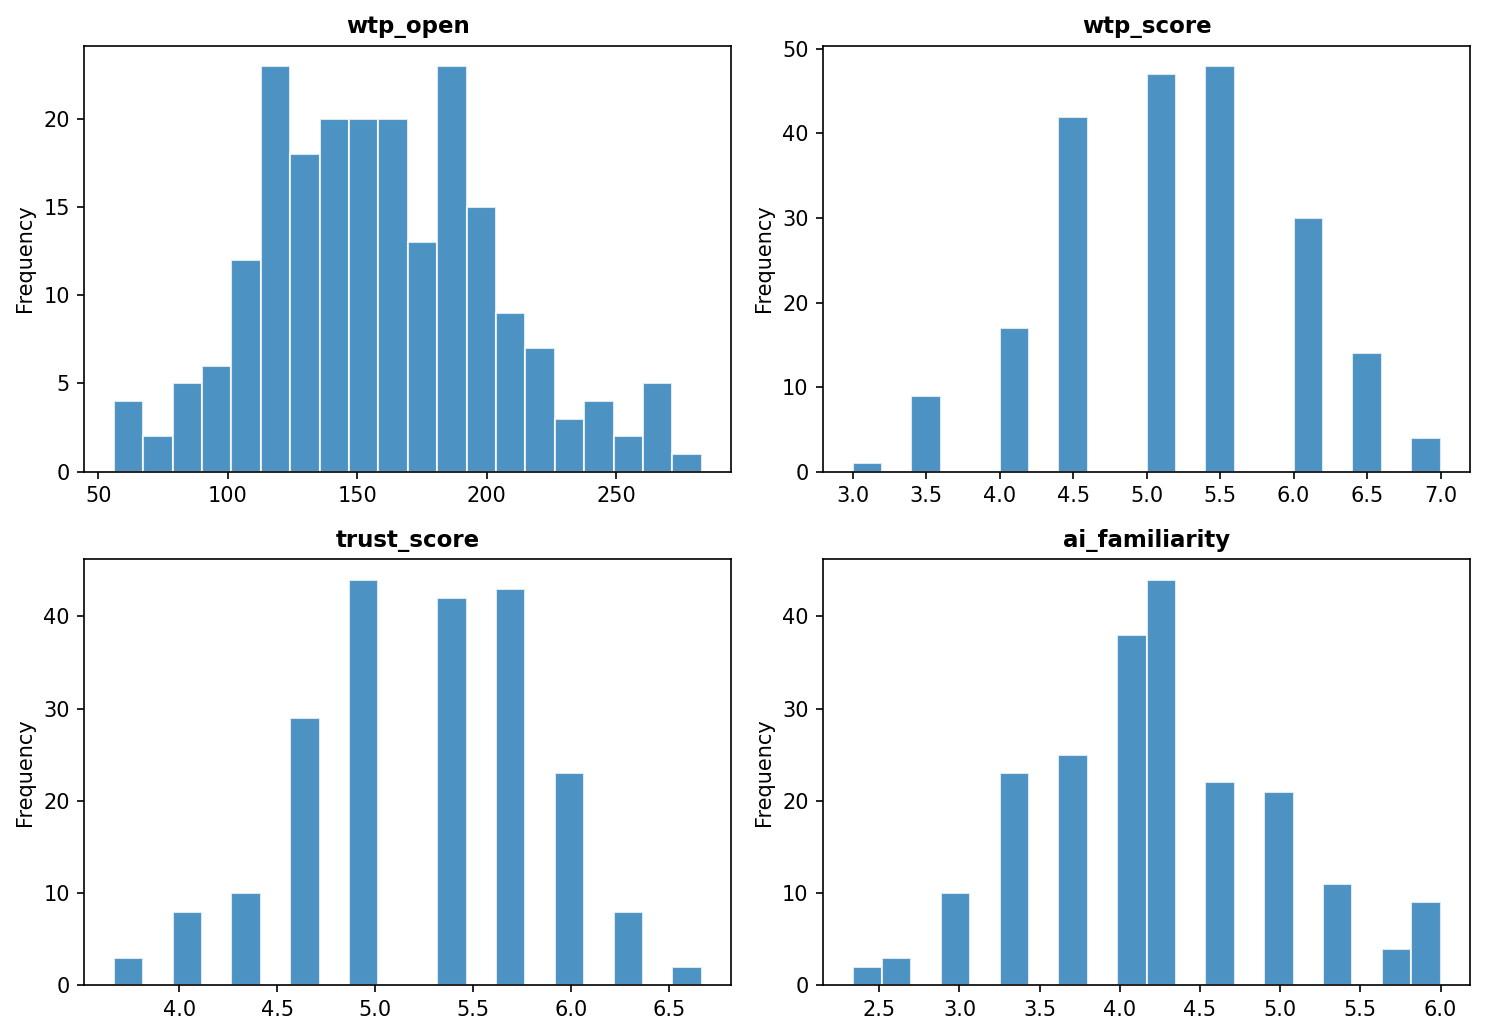

In [6]:
key_num_vars = ["wtp_open", "wtp_score", "trust_score", "ai_familiarity"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, var in zip(axes.flatten(), key_num_vars):
    ax.hist(df[var].dropna(), bins=20, edgecolor="white", alpha=0.8)
    ax.set_title(var, fontsize=11, fontweight="bold")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [7]:
skew_df = df[key_num_vars].skew().round(2).to_frame("skewness")
skew_df["interpretation"] = skew_df["skewness"].apply(
    lambda x: "Roughly symmetric" if abs(x) < 1 else ("Right-skewed" if x > 0 else "Left-skewed")
)
skew_df


,skewness,interpretation
wtp_open,0.32,Roughly symmetric
wtp_score,-0.03,Roughly symmetric
trust_score,-0.25,Roughly symmetric
ai_familiarity,0.24,Roughly symmetric


## Section 3: Group Comparison (2×2 Experimental Design)

Your study has four scenarios:

- 实验情境1: AI-designed × high added value  
- 实验情境2: AI-designed × low added value  
- 实验情境3: professional design team × high added value  
- 实验情境4: professional design team × low added value  

So group means are one of the most important EDA outputs.


In [8]:
group_means = df.groupby("group")[["wtp_open", "wtp_score", "trust_score", "ai_familiarity", "mc_ai", "mc_value"]].agg(["mean", "std", "count"]).round(2)
group_means


wtp_open              wtp_score        ... mc_ai       mc_value            
          mean    std count      mean   std  ...   std count     mean   std count
group                                        ...                                 
实验情境1   193.39  42.56    54      5.82  0.64  ...  0.66    54     5.93  0.84    54
实验情境2   143.52  32.29    46      5.02  0.61  ...  0.77    46     2.48  1.03    46
实验情境3   168.38  38.77    60      5.17  0.71  ...  0.72    60     5.65  0.84    60
实验情境4   123.48  32.41    52      4.50  0.66  ...  0.68    52     2.50  0.90    52

[4 rows x 18 columns]

/tmp/ipykernel_3688/1227242530.py:13: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3688/1227242530.py:13: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3688/1227242530.py:13: UserWarning: Glyph 24773 (\N{CJK UNIFIED IDEOGRAPH-60C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3688/1227242530.py:13: UserWarning: Glyph 22659 (\N{CJK UNIFIED IDEOGRAPH-5883}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

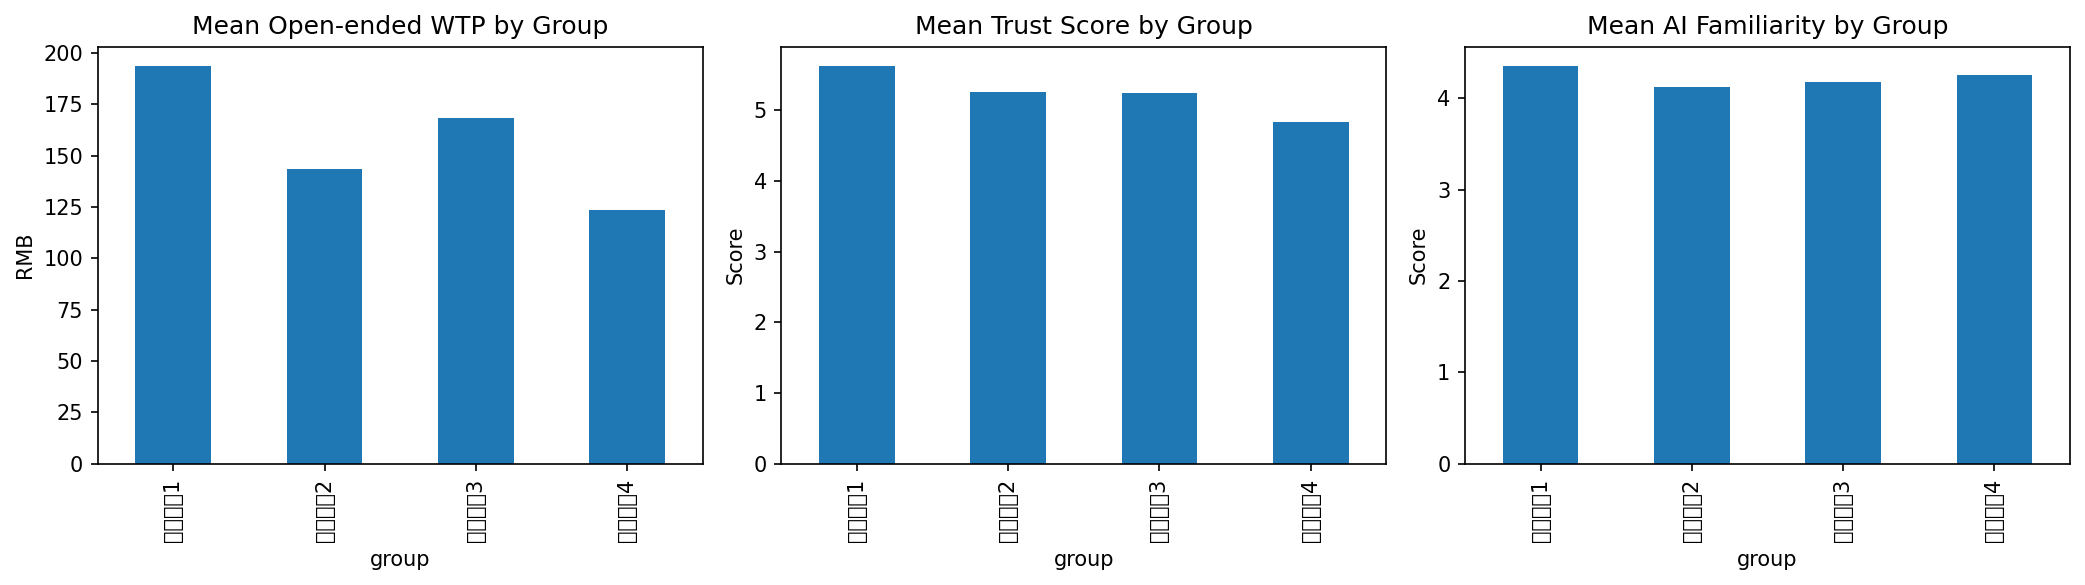

In [9]:
mean_table = df.groupby("group")[["wtp_open", "wtp_score", "trust_score", "ai_familiarity"]].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
mean_table["wtp_open"].plot(kind="bar", ax=axes[0], title="Mean Open-ended WTP by Group")
axes[0].set_ylabel("RMB")

mean_table["trust_score"].plot(kind="bar", ax=axes[1], title="Mean Trust Score by Group")
axes[1].set_ylabel("Score")

mean_table["ai_familiarity"].plot(kind="bar", ax=axes[2], title="Mean AI Familiarity by Group")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()


### Quick interpretation

For this project, the two most important questions at the EDA stage are:

1. Do the AI-designed groups show higher willingness to pay than the professional-design groups?  
2. Does the high added-value condition appear to change that pattern?


## Section 4: Manipulation Check

Before testing hypotheses, confirm that the manipulations worked.

- `mc_ai` should be higher in AI-design groups  
- `mc_value` should be higher in high added-value groups


In [10]:
mc_table = df.groupby("group")[["mc_ai", "mc_value"]].mean().round(2)
mc_table


,mc_ai,mc_value
group,,
实验情境1,6.15,5.93
实验情境2,6.24,2.48
实验情境3,1.72,5.65
实验情境4,1.75,2.50


## Section 5: Correlations

Correlation is a useful first look at how the main constructs move together before regression.


In [11]:
corr_vars = ["wtp_open", "wtp_score", "trust_score", "ai_familiarity", "design_source", "added_value"]
corr = df[corr_vars].corr().round(2)
corr


,wtp_open,wtp_score,trust_score,ai_familiarity,design_source,added_value
wtp_open,1.00,0.41,0.42,-0.03,0.25,0.52
wtp_score,0.41,1.00,0.43,-0.05,0.37,0.45
trust_score,0.42,0.43,1.00,-0.03,0.34,0.32
ai_familiarity,-0.03,-0.05,-0.03,1.00,0.01,0.04
design_source,0.25,0.37,0.34,0.01,1.00,0.00
added_value,0.52,0.45,0.32,0.04,0.00,1.00


## Section 6: Reliability Checks

Because several constructs are measured with multiple questionnaire items, we should check internal consistency before relying on the scale scores.


In [12]:
def cronbach_alpha(items_df):
    items = items_df.dropna()
    item_vars = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    n_items = items.shape[1]
    return n_items / (n_items - 1) * (1 - item_vars.sum() / total_var)

alphas = {
    "wtp_alpha": cronbach_alpha(df[["wtp_1", "wtp_2"]]),
    "trust_alpha": cronbach_alpha(df[["trust_1", "trust_2", "trust_3"]]),
    "ai_familiarity_alpha": cronbach_alpha(df[["fam_1", "fam_2", "fam_3"]]),
}
pd.Series(alphas).round(3).to_frame("alpha")


,alpha
wtp_alpha,0.374
trust_alpha,0.356
ai_familiarity_alpha,0.369


## Section 7: Hypothesis-Oriented Analysis

At the EDA stage, we do not need the final polished model yet. But we can already run simple regressions aligned with the hypotheses.


In [13]:
# H1: AI vs professional design
h1_model = smf.ols("wtp_open ~ design_source", data=df).fit()
print(h1_model.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     14.45
Date:                Fri, 15 May 2026   Prob (F-statistic):           0.000189
Time:                        13:58:36   Log-Likelihood:                -1101.2
No. Observations:                 212   AIC:                             2206.
Df Residuals:                     210   BIC:                             2213.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       147.5357      4.140     35.636

In [14]:
# H2: Trust positively affects WTP
h2_model = smf.ols("wtp_open ~ trust_score", data=df).fit()
print(h2_model.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     44.25
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.46e-10
Time:                        13:58:36   Log-Likelihood:                -1087.9
No. Observations:                 212   AIC:                             2180.
Df Residuals:                     210   BIC:                             2187.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -7.2851     25.058     -0.291      

In [15]:
# H3a: AI familiarity moderates the effect of design source
h3a_model = smf.ols("wtp_open ~ design_source * ai_familiarity", data=df).fit()
print(h3a_model.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     5.156
Date:                Fri, 15 May 2026   Prob (F-statistic):            0.00185
Time:                        13:58:36   Log-Likelihood:                -1100.6
No. Observations:                 212   AIC:                             2209.
Df Residuals:                     208   BIC:                             2223.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [16]:
# H4: product added value moderates the effect of design source
h4_model = smf.ols("wtp_open ~ design_source * added_value", data=df).fit()
print(h4_model.summary())


                            OLS Regression Results                            
Dep. Variable:               wtp_open   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     35.41
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.56e-18
Time:                        13:58:36   Log-Likelihood:                -1064.5
No. Observations:                 212   AIC:                             2137.
Df Residuals:                     208   BIC:                             2150.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## Section 8: Main Takeaways from EDA

You can adapt these points for your Assignment 3 report or later paper draft:

- The dataset contains 212 cleaned responses and 21 variables.
- The four experimental groups are reasonably balanced.
- No missing values or duplicate rows remain after cleaning.
- Group means suggest that willingness to pay differs across the four scenarios.
- Manipulation-check variables behave as expected, which supports the validity of the scenario design.
- Trust is positively associated with willingness to pay in the preliminary analysis.
- The next step is to refine the regression models and present the results more formally in the final paper.
